# **패혈증 진단 예측 모델**

In [2]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Mounted at /content/drive


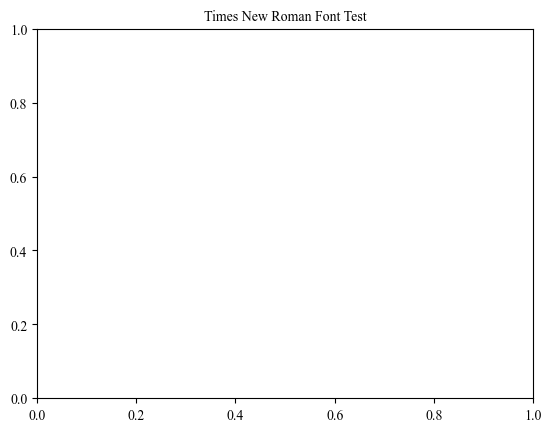

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 파일의 경로를 직접 입력
font_path = '/content/drive/MyDrive/TimesNewerRoman/Times New Roman.ttf'

# 폰트를 Matplotlib 폰트 관리자에 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

# 테스트
plt.title("Times New Roman Font Test", fontproperties=font_prop)
plt.show()

✅ 데이터 준비 완료 (사용한 변수 개수: 44개)

[모델 학습 시작]
✅ Random Forest: AUC=0.8655, Best Threshold=0.0296
✅ XGBoost: AUC=0.8442, Best Threshold=0.0512
[LightGBM] [Info] Number of positive: 2130, number of negative: 32406
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5319
[LightGBM] [Info] Number of data points in the train set: 34536, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
✅ LightGBM: AUC=0.8801, Best Threshold=0.1719
✅ Logistic Regression: AUC=0.8619, Best Threshold=0.2778


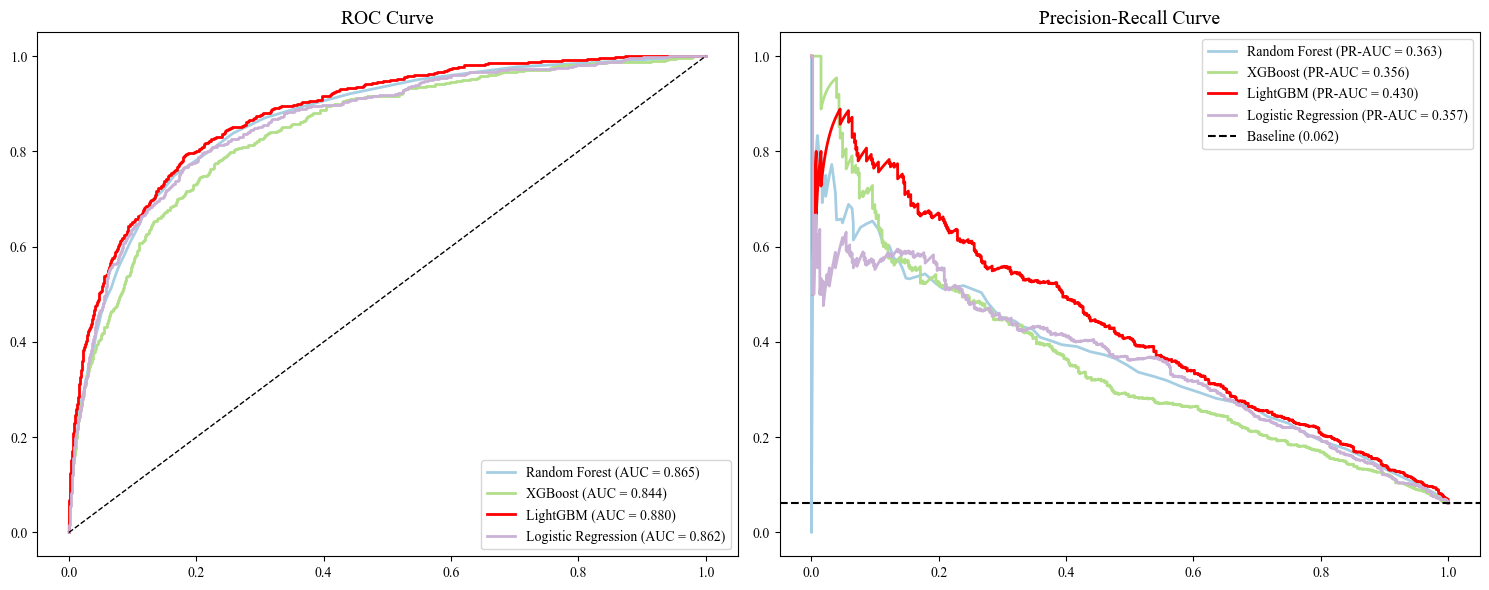

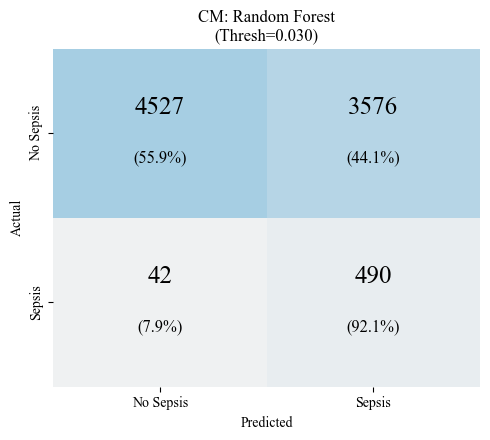

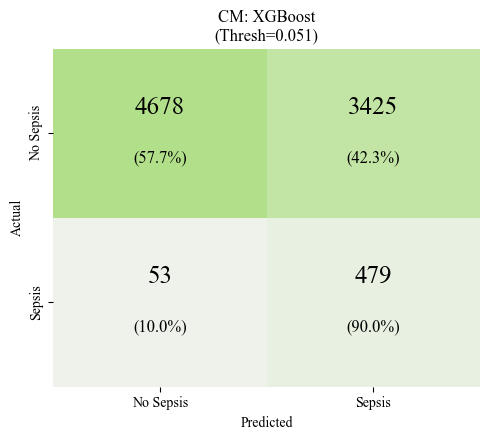

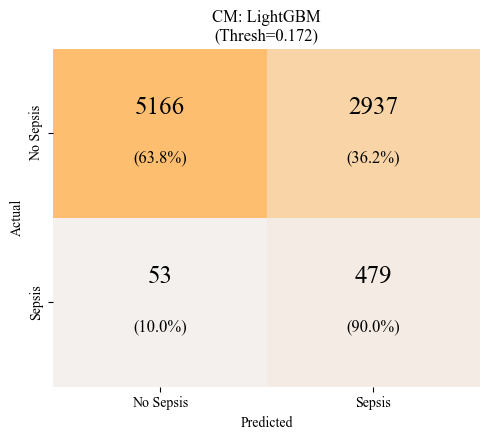

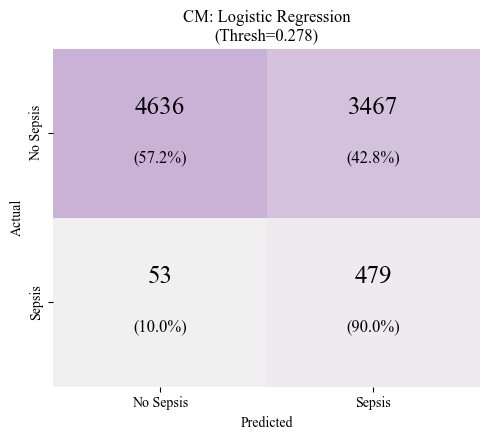


로지스틱 회귀: Odds Ratio (OR) 분석
                   Feature        OR      Coef
33      RESP_RATE_measured  1.891721  0.637487
0                      WBC  1.651643  0.501770
12        AGE_AT_ADMISSION  1.491975  0.400101
5                   SODIUM  1.347014  0.297890
43  URINE_PROTEIN_measured  1.307404  0.268043
34           TEMP_measured  1.254280  0.226562
37           PAO2_measured  1.203106  0.184906
22              HEART_RATE  1.160675  0.149002
13                  GENDER  1.131300  0.123367
17                     INR  1.126040  0.118707
38           FIO2_measured  1.124845  0.117645
25                     MAP  1.121012  0.114232
26               RESP_RATE  1.118196  0.111717
14                 LACTATE  1.102754  0.097811
3               CREATININE  1.088162  0.084490

로지스틱 회귀 Threshold 최적화 비교
       Method  Threshold  Precision  Recall      F1  Specificity
0     Default     0.5000     0.2112  0.7707  0.3316       0.8111
1      Max F1     0.7524     0.3633  0.5470  0.4366       0.937

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


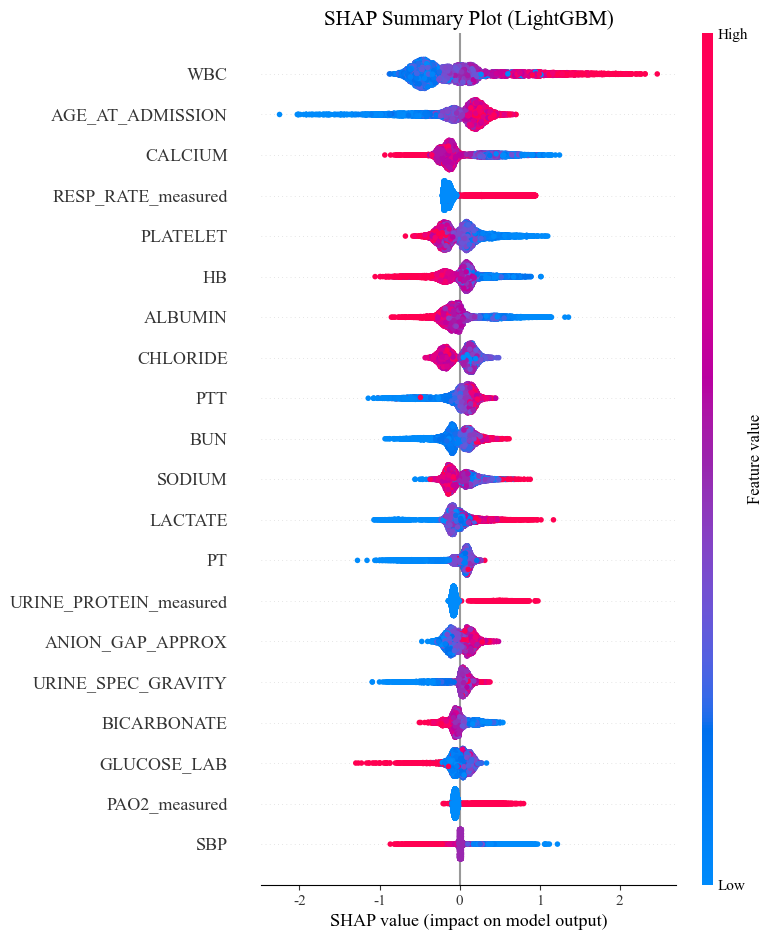


🎯 분석 요약
  - Random Forest: AUC=0.8655, PR-AUC=0.3629, Recall=0.9211, Accuracy=0.5810
  - XGBoost: AUC=0.8442, PR-AUC=0.3559, Recall=0.9004, Accuracy=0.5972
  - LightGBM: AUC=0.8801, PR-AUC=0.4301, Recall=0.9004, Accuracy=0.6537
  - Logistic Regression: AUC=0.8619, PR-AUC=0.3572, Recall=0.9004, Accuracy=0.5924
주요 사망 위험 요인(OR 상위): RESP_RATE_measured (OR: 1.89)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score
)
# 0. 설정 및 색상
base_path = '/content/drive/MyDrive/ColabNotebooks/'
figures_path = f'{base_path}figures'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': "red", # LightGBM will be red for ROC/PRC
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리 (패혈증 모델이므로 'HOSPITAL_EXPIRE_FLAG' 제외)
target = 'SEPSIS'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")

# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss',
                             scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Recall 0.9 기반 최적 임계값 찾기 (for the current model)
    recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
    valid_idx = np.where(np.array(recalls) >= 0.90)[0]
    best_threshold = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

    # 최적 임계값으로 예측 (for the current model)
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    # Calculate precision and recall for PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'recall': recall_score(y_test, y_pred_optimal),
        'accuracy': accuracy_score(y_test, y_pred_optimal),
        'model': model
    }
    print(f"✅ {name}: AUC={results[name]['auc']:.4f}, Best Threshold={best_threshold:.4f}")

# 4-1. 시각화 (ROC & PRC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=model_colors[name], lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=model_colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend()

# Save ROC and PRC curves before showing
plt.tight_layout()
plt.savefig(f'{figures_path}/roc_prc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4-2. 시각화: Confusion Matrix (최적 임계값 반영)
# Create and save a separate figure for each confusion matrix
for name, res in results.items():
    fig, ax = plt.subplots(figsize=(5, 4.5)) # Create a new figure for each model
    cm = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Calculate percentages

    # Use the original color from color_list for LightGBM in confusion matrix
    current_model_color = color_list[2] if name == 'LightGBM' else model_colors[name]
    cmap = sns.light_palette(current_model_color, as_cmap=True)
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])

    # Manually add annotations with different font sizes and positions
    for (j, k), count in np.ndenumerate(cm):
        percentage = cm_norm[j, k]
        ax.text(k + 0.5, j + 0.35, f"{count}",
                ha='center', va='center', fontsize=18, color='black', fontweight='bold') # Large, bold count
        ax.text(k + 0.5, j + 0.65, f"({percentage:.1%})",
                ha='center', va='center', fontsize=12, color='black') # Smaller percentage

    ax.set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Save each confusion matrix plot individually
    plt.tight_layout()
    plt.savefig(f'{figures_path}/confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 5. 로지스틱 회귀 Odds Ratio 분석
print("\n" + "="*80)
print("로지스틱 회귀: Odds Ratio (OR) 분석")
lr_res = results['Logistic Regression']
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(lr_res['model'].coef_[0]),
    'Coef': lr_res['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(or_df.head(15))

# 6. 로지스틱 회귀 전용 Threshold 비교
print("\n" + "="*80)
print("로지스틱 회귀 Threshold 최적화 비교")
y_test_proba = lr_res['prob']
thresh_results = []

f1_scores = [f1_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores)]

recalls = [recall_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx = np.where(np.array(recalls) >= 0.90)[0]
best_rec_t = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t), ("Youden's J", lr_res['threshold']), ('Recall 0.9', best_rec_t)]:
    preds = (y_test_proba >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    thresh_results.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4)
    })
print(pd.DataFrame(thresh_results))

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)

# Save SHAP plot before showing
plt.tight_layout()
plt.savefig(f'{figures_path}/shap_summary_plot_LightGBM.png', dpi=300, bbox_inches='tight')
plt.show()

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}, Recall={res['recall']:.4f}, Accuracy={res['accuracy']:.4f}")
print(f"주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, roc_curve # Added roc_curve import

print("\n" + "="*80)
print("LightGBM Threshold 최적화 비교")

# Assuming 'results' and 'y_test' are available from previous executions
# Re-extract LightGBM results to ensure fresh data
lgbm_res = results['LightGBM']
y_test_proba_lgbm = lgbm_res['prob']

# Calculate Youden's J for LightGBM
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_test_proba_lgbm)
youden_j_scores_lgbm = tpr_lgbm - fpr_lgbm
best_youden_j_t_lgbm = thresholds_lgbm[np.argmax(youden_j_scores_lgbm)]

# F1-score 기반 최적 임계값 찾기
f1_scores_lgbm = [f1_score(y_test, (y_test_proba_lgbm >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t_lgbm = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores_lgbm)]

# Recall 0.9 기반 최적 임계값 찾기
recalls_lgbm = [recall_score(y_test, (y_test_proba_lgbm >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx_lgbm = np.where(np.array(recalls_lgbm) >= 0.90)[0]
best_rec_t_lgbm = np.linspace(0.01, 0.99, 1000)[valid_idx_lgbm[-1]] if len(valid_idx_lgbm) > 0 else 0.5

# Re-create the list of dictionaries with all required metrics
temp_thresh_results_lgbm = []
for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t_lgbm), ("Youden's J", best_youden_j_t_lgbm), ('Recall 0.9', best_rec_t_lgbm)]:
    preds = (y_test_proba_lgbm >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    temp_thresh_results_lgbm.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })

# Convert the correctly formed list of dictionaries to a DataFrame and display
df_lgbm_threshold_comparison = pd.DataFrame(temp_thresh_results_lgbm)
display(df_lgbm_threshold_comparison.round(4))


LightGBM Threshold 최적화 비교


,Method,Threshold,Precision,Recall,F1,Specificity,TN,FP,FN,TP
0,Default,0.5000,0.2528,0.7180,0.3740,0.8607,6974,1129,150,382
1,Max F1,0.7821,0.4346,0.4680,0.4507,0.9600,7779,324,283,249
2,Youden's J,0.3946,0.2205,0.7951,0.3453,0.8155,6608,1495,109,423
3,Recall 0.9,0.1719,0.1402,0.9004,0.2427,0.6375,5166,2937,53,479


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 0. 설정 및 색상
base_path = '/content/drive/MyDrive/ColabNotebooks/'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': color_list[2],
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리 (패혈증 모델이므로 'HOSPITAL_EXPIRE_FLAG' 제외)
target = 'SEPSIS'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")

# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss',
                             scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 및 Youden's Index 최적화 시작]")
for name, model in models_dict.items(): # Changed 'models' to 'models_dict'
    if name == 'Logistic Regression': # Use scaled data for Logistic Regression
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    # --- Youden's Index 기반 최적 임계값 찾기 ---
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    # J = Sensitivity + Specificity - 1 = TPR - FPR
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]

    # 최적 임계값을 적용한 예측값 생성
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    # Calculate precision and recall for PR-AUC (renamed to avoid conflict)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)

    # Calculate actual metrics for the best threshold
    current_recall = recall_score(y_test, y_pred_optimal)
    current_accuracy = accuracy_score(y_test, y_pred_optimal)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall_curve, precision_curve),
        'recall': current_recall, # Add actual recall
        'accuracy': current_accuracy, # Add actual accuracy
        'model': model
    }
    print(f"✅ {name}: AUC={results[name]['auc']:.4f}, Best Threshold={best_threshold:.4f}")

# 4-1. 시각화 (ROC & PRC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=model_colors[name], lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=model_colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend()
plt.show()

# 4-2. 시각화: Confusion Matrix (최적 임계값 반영)
# Fix: Create enough subplots for all models
fig, axes = plt.subplots(1, len(results), figsize=(len(results) * 5, 4.5))
# Ensure axes is always iterable, even if there's only one subplot
if len(results) == 1:
    axes = [axes]

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    cmap = sns.light_palette(model_colors[name], as_cmap=True)

    # Correct definition of group_names to match cm.flatten() order (TN, FP, FN, TP)
    # y_test values (True Label) are 0=No Sepsis, 1=Sepsis.
    # cm[0,0] = True Negative (True No Sepsis, Predicted No Sepsis)
    # cm[0,1] = False Positive (True No Sepsis, Predicted Sepsis)
    # cm[1,0] = False Negative (True Sepsis, Predicted No Sepsis)
    # cm[1,1] = True Positive (True Sepsis, Predicted Sepsis)
    group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    group_labels_short = ['TN', 'FP', 'FN', 'TP']

    group_counts = cm.flatten() # Raw counts
    total_count = np.sum(group_counts)
    group_percentages = [f'{value/total_count:.1%}' for value in group_counts]

    labels = []
    for i_label in range(4):
        # Combine full name, short label, count, and percentage.
        # Use annot_kws to control global font size and boldness for annotations.
        labels.append(f'{group_names[i_label]} ({group_labels_short[i_label]})\n{group_counts[i_label]}\n{group_percentages[i_label]}')

    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap, ax=axes[i], cbar=False,
                xticklabels=['No Sepsis', 'Sepsis'], # Corrected order for Predicted Labels
                yticklabels=['No Sepsis', 'Sepsis'], # Corrected order for True Labels
                annot_kws={"size": 12, "fontweight": "bold"}) # Apply boldness and size via annot_kws
    axes[i].set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
plt.tight_layout()
plt.show()

# 5. 로지스틱 회귀 Odds Ratio 분석
print("\n" + "="*80)
print("로지스틱 회귀: Odds Ratio (OR) 분석")
lr_res = results['Logistic Regression']
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(lr_res['model'].coef_[0]),
    'Coef': lr_res['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(or_df.head(15))

# 6. 로지스틱 회귀 전용 Threshold 비교
print("\n" + "="*80)
print("로지스틱 회귀 Threshold 최적화 비교")
y_test_proba = lr_res['prob']
thresh_results = []

f1_scores = [f1_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores)]

recalls = [recall_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx = np.where(np.array(recalls) >= 0.90)[0]
best_rec_t = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t), ("Youden's J", lr_res['threshold']), ('Recall 0.9', best_rec_t)]:
    preds = (y_test_proba >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    thresh_results.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4)
    })
print(pd.DataFrame(thresh_results))

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
# For TreeExplainer with binary classification, shap_values is often a list of two arrays.
# We need the values for the positive class (index 1).
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Take shap values for the positive class

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)
plt.show()

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}, Recall={res['recall']:.4f}, Accuracy={res['accuracy']:.4f}")
print(f"주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")